# END-TO-END MACHINE LEARNING SYSTEM FOR CUSTOMER CHURN PREDICTION & BUSINESS RISK ANALYSIS

## Executive Project Overview

**Objective:** Build a production-oriented customer-churn classification system that demonstrates data understanding, robust preprocessing and feature engineering, disciplined model selection and tuning, evaluation beyond accuracy, model interpretability, and business actionability.

### Business problem

Customer churn occurs when an existing customer terminates or stops using the company's service. Predicting churn is valuable because retention teams have limited resources and need to identify customers who are most likely to leave **before** the churn event occurs.

The business objective is therefore not simply to maximize classification accuracy. It is to produce **reliable churn probabilities that can prioritize retention activity**, while explicitly considering the cost of false positives and false negatives.

### Business cost of prediction errors

- **False Negative:** A customer who will churn is predicted as low risk. The company may miss an opportunity to intervene and potentially lose the customer's future revenue/lifetime value.
- **False Positive:** A customer who would remain is predicted as high risk. The company may spend unnecessary retention resources, discounts, or service incentives.
- Because the relative cost of these errors is business-dependent, precision, recall, F1-score, ROC-AUC, confusion matrices, probability thresholds, and risk segmentation are evaluated rather than relying on accuracy alone.

### Analytical strategy

The project follows the complete ML lifecycle:

**Business understanding → Data quality → EDA → Feature engineering → Preprocessing → Stratified train/test split → Baseline models → Cross-validation → Hyperparameter tuning → Locked model selection → Final holdout evaluation → Interpretability → Risk segmentation → Business recommendations → Model/prediction export**

> **Important validation principle:** The test set is treated as an unseen final holdout. Cross-validation on the training data is used for model comparison and hyperparameter selection; the test set is not used to choose the winning model.

## Mandatory Coverage Map

| Assignment requirement | Where demonstrated |
|---|---|
| Problem understanding & business context | Executive overview and business-risk discussion |
| Data shape, types, missing values | Data quality section |
| Numerical & categorical univariate EDA | EDA section |
| Bivariate analysis with churn | Churn-rate tables/charts |
| Class imbalance | Target distribution section |
| Plot interpretation | Interpretation notes throughout EDA |
| Missing-value handling + justification | Data cleaning + preprocessing |
| Outlier review/treatment decision | IQR review + explicit treatment rationale |
| Encoding strategy | One-Hot Encoding rationale |
| Feature scaling | StandardScaler rationale |
| ≥3 engineered features | `TelcoFeatureEngineer` |
| Irrelevant/leakage-prone features | Identifier/target separation |
| Stratified train/test split | Train-test section |
| Reproducibility | Fixed `random_state` + package versions |
| 5 required models | Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, SVM |
| Hyperparameter tuning | `RandomizedSearchCV` |
| Parameter rationale | Tuning strategy notes |
| Before vs after tuning | Comparison table |
| K-fold CV + mean/std | 5-fold baseline CV and 3-fold tuning CV reporting |
| Required evaluation metrics | Accuracy, Precision, Recall, F1, ROC-AUC, confusion matrix |
| Metric trade-offs | Evaluation/business analysis |
| Tree feature importance | Interpretability section |
| Logistic coefficients | Interpretability section |
| Business meaning of predictors | Interpretability/business recommendations |
| Pipeline / ColumnTransformer | End-to-end sklearn pipeline |
| Clean/no hard-coded paths | Project-relative paths |
| Risk segmentation | Probability-based High/Medium/Low tiers |
| Business recommendations | Final business-risk section |
| Prediction output | CSV export |
| Saved model | `.joblib` pipeline export |

In [1]:
# Import all necessary libraries and dependencies.
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import matplotlib
import sys
import seaborn

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    ConfusionMatrixDisplay
)

from sklearn.inspection import permutation_importance

import joblib

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

In [2]:
# Project-relative paths: no machine-specific absolute paths.
# The notebook expects Telco-Customer-Churn.csv to be in the notebook's working directory.

NOTEBOOK_DIR = Path.cwd()
DATA_PATH = NOTEBOOK_DIR / "Telco-Customer-Churn.csv"

OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"

for folder in [OUTPUT_DIR, FIGURES_DIR, MODELS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Working directory: {NOTEBOOK_DIR}")
print(f"Data path: {DATA_PATH}")
print(f"Data file exists: {DATA_PATH.exists()}")

assert DATA_PATH.exists(), (
    "Telco-Customer-Churn.csv was not found in the notebook working directory. "
    "Place the dataset beside the notebook and rerun."
)

Working directory: C:\Users\Henry\Career Amend data science\PROJECTS AND ASSIGNMENTS\AMLCUSTOMERCHURN
Data path: C:\Users\Henry\Career Amend data science\PROJECTS AND ASSIGNMENTS\AMLCUSTOMERCHURN\Telco-Customer-Churn.csv
Data file exists: True


In [3]:
# load raw dataset and get general overview
df_raw = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df_raw.shape[0]:,} rows and {df_raw.shape[1]} columns")
display(df_raw.head())

Dataset shape: 7,043 rows and 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**DATA CLEANING AND DATA PREPROCESSING**

In [4]:
# TotalCharges is stored as text because blank strings represent missing values.
# Convert whitespace-only strings to NaN, then convert the column to numeric.

df_raw["TotalCharges"] = df_raw["TotalCharges"].replace(r"^\s*$", np.nan, regex=True)
df_raw["TotalCharges"] = pd.to_numeric(df_raw["TotalCharges"], errors="coerce")

print(f"Missing values in TotalCharges after numeric conversion: {df_raw['TotalCharges'].isna().sum():,}")

Missing values in TotalCharges after numeric conversion: 11


In [5]:
# Create the modeling dataframe and validate the missing-value pattern.
df = df_raw.copy()

missing_totalcharges = df["TotalCharges"].isna()
display(
    df.loc[
        missing_totalcharges,
        ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]
    ].head(12)
)

# In this dataset, missing TotalCharges occurs for customers with zero tenure.
# Zero is therefore a domain-consistent value for cumulative charges at the
# start of the customer relationship.
if missing_totalcharges.any():
    assert (df.loc[missing_totalcharges, "tenure"] == 0).all(), (
        "Unexpected missing values in TotalCharges was found outside zero-tenure customers."
    )

print(f"Rows with missing TotalCharges: {missing_totalcharges.sum():,}")

,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


Rows with missing TotalCharges: 11


In [6]:
# Domain-informed imputation:
# a zero-tenure customer has accumulated zero historical charges. (tenure = 0)
df["TotalCharges"] = df["TotalCharges"].fillna(0)

#Verify no missing values remain
print(f"Remaining missing values in TotalCharges: {df['TotalCharges'].isna().sum():,}")

Remaining missing values in TotalCharges: 0


In [7]:
# Data quality summary table
quality_summary = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Missing Values": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2),
    "Unique Values": df.nunique()
}).sort_values(["Missing Values", "Unique Values"], ascending=[False, False])

display(quality_summary)

,Data Type,Missing Values,Missing %,Unique Values
customerID,str,0,0.0,7043
TotalCharges,float64,0,0.0,6531
MonthlyCharges,float64,0,0.0,1585
tenure,int64,0,0.0,73
PaymentMethod,str,0,0.0,4
MultipleLines,str,0,0.0,3
InternetService,str,0,0.0,3
OnlineSecurity,str,0,0.0,3
OnlineBackup,str,0,0.0,3
DeviceProtection,str,0,0.0,3


**EXPLORATORY DATA ANALYSIS**

**Target Variable Distribution**

,Churn,Customer Count,Percentage
0,No,5174,73.46
1,Yes,1869,26.54


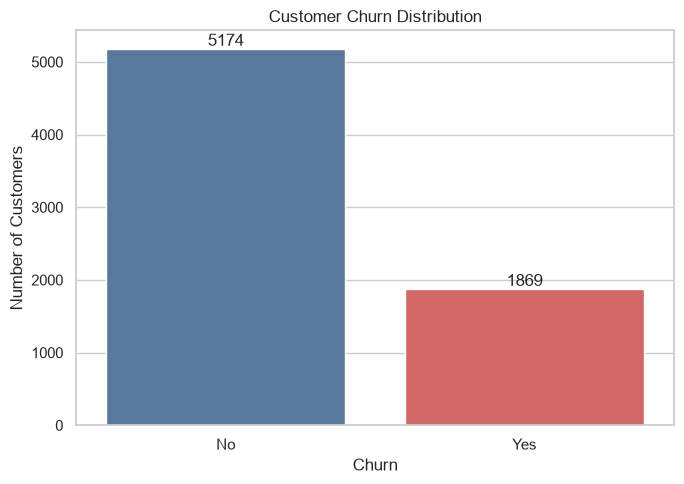

In [8]:
# Target Variable Distribution
churn_summary = (
    df["Churn"]
    .value_counts()
    .rename_axis("Churn")
    .reset_index(name="Customer Count")
)

churn_summary["Percentage"] = (
    churn_summary["Customer Count"] / churn_summary["Customer Count"].sum() * 100
).round(2)

display(churn_summary)

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x="Churn", hue="Churn", palette=["#4C78A8", "#E45756"], legend=False)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "churn_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

> Of the 7,043 customers in the dataset, 1,869 (26.54%) churned while 5,174 (73.46%) were retained. This represents a moderate class imbalance rather than a severe one, since the minority class still makes up more than a quarter of all observations.

> Because roughly 1 in 4 customers churned, a naive model that always predicts "No churn" would already achieve 73.46% accuracy — this is the baseline the actual model must beat, and it underscores why accuracy alone is a misleading metric here. To account for this imbalance, stratify=y will be used when creating the train-test split so both sets preserve the same ~73/27 ratio, and evaluation will prioritize recall, F1-score,
and ROC-AUC for the churn class over raw accuracy.

**Numerical Univariate Analysis**

### EDA Interpretation — Numerical Distributions

The numerical distributions provide the range, central tendency, spread, and potential extreme values of tenure, MonthlyCharges, and TotalCharges. Tenure and TotalCharges are expected to be right-skewed because customers accumulate charges over time. These distributions justify robust preprocessing and motivate the later engineered measures such as average monthly spend.

The boxplots are used to distinguish unusual values from potential data-quality errors; unusual values are not automatically treated as invalid.

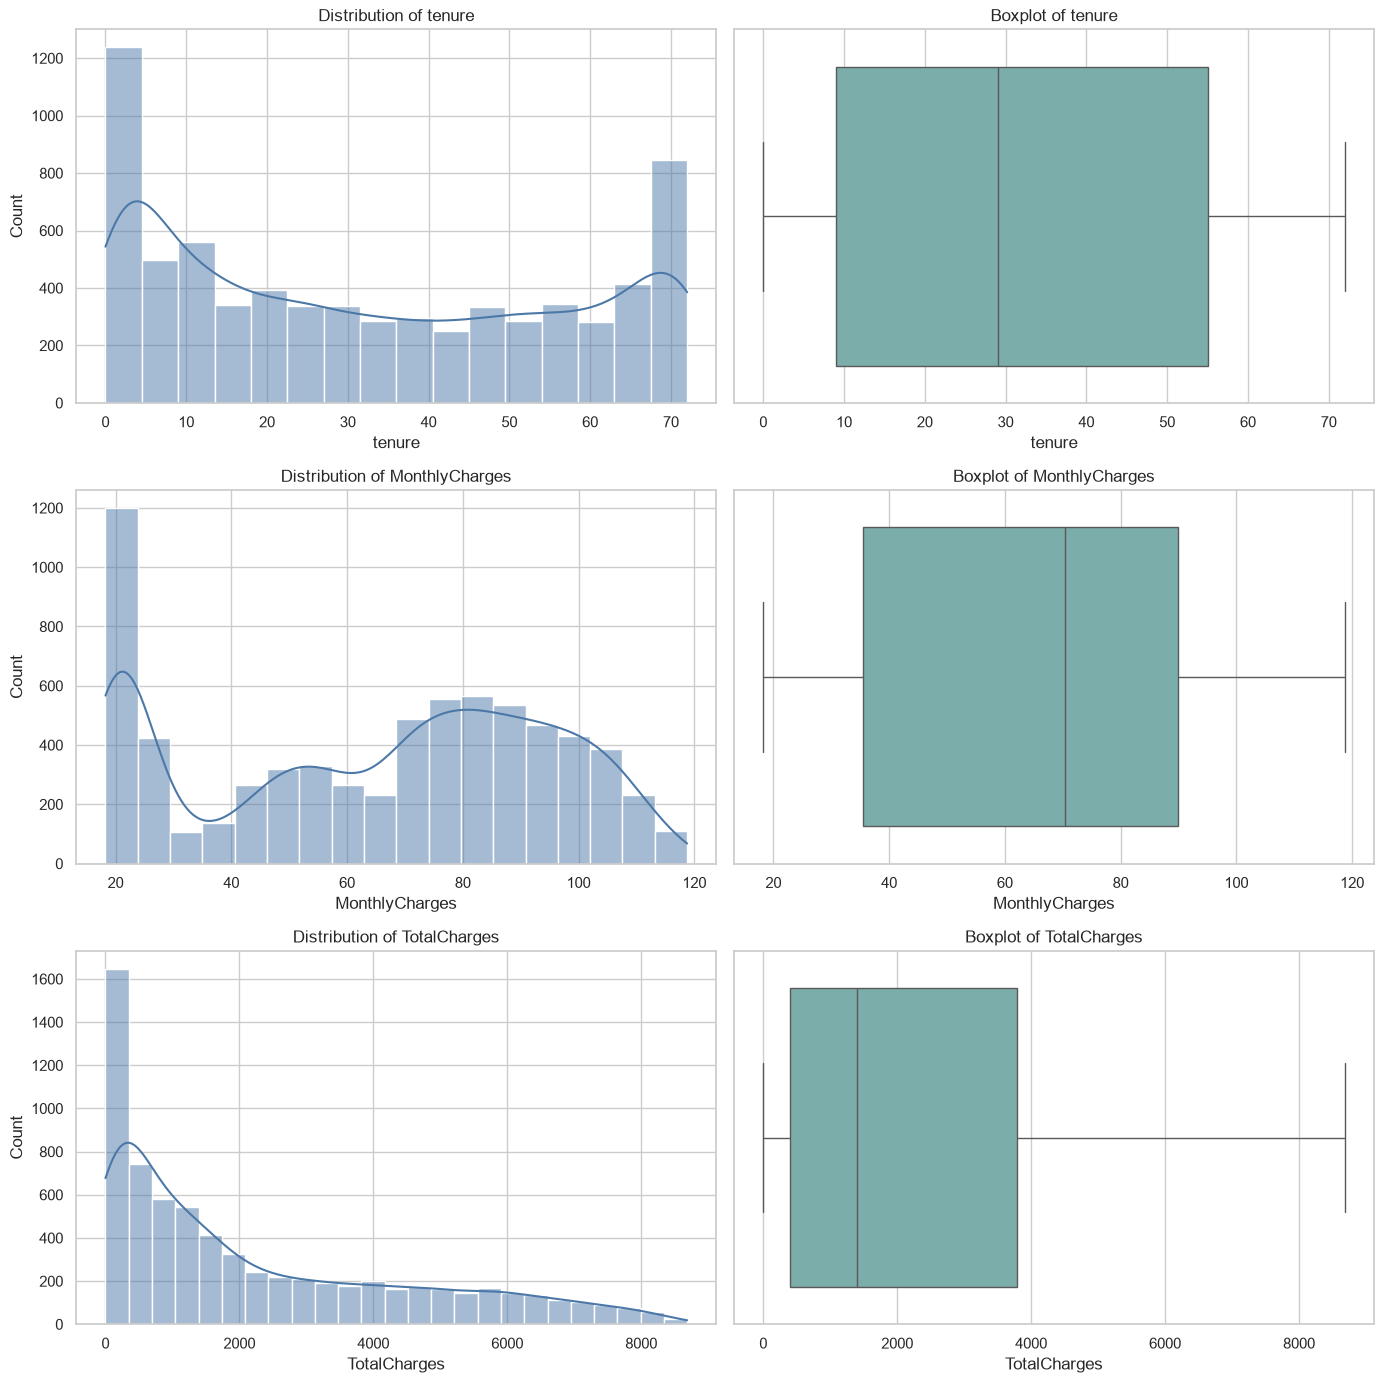

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


In [9]:
numeric_eda_features = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(14, 14))

for row, feature in enumerate(numeric_eda_features):
    sns.histplot(
        data=df,
        x=feature,
        kde=True,
        ax=axes[row, 0],
        color="#4C78A8"
    )
    axes[row, 0].set_title(f"Distribution of {feature}")

    sns.boxplot(
        data=df,
        x=feature,
        ax=axes[row, 1],
        color="#72B7B2"
    )
    axes[row, 1].set_title(f"Boxplot of {feature}")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "numerical_univariate_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

display(df[numeric_eda_features].describe().T)

**Categorical Univariate Analysis**

### EDA Interpretation — Categorical Distributions

The categorical distributions show how the customer base is composed across contract, service, payment, and billing characteristics. Understanding these base rates matters because a category can appear highly associated with churn partly because it contains a very large or very small number of customers.

The subsequent bivariate churn-rate analysis therefore complements these univariate counts by directly examining the target relationship.

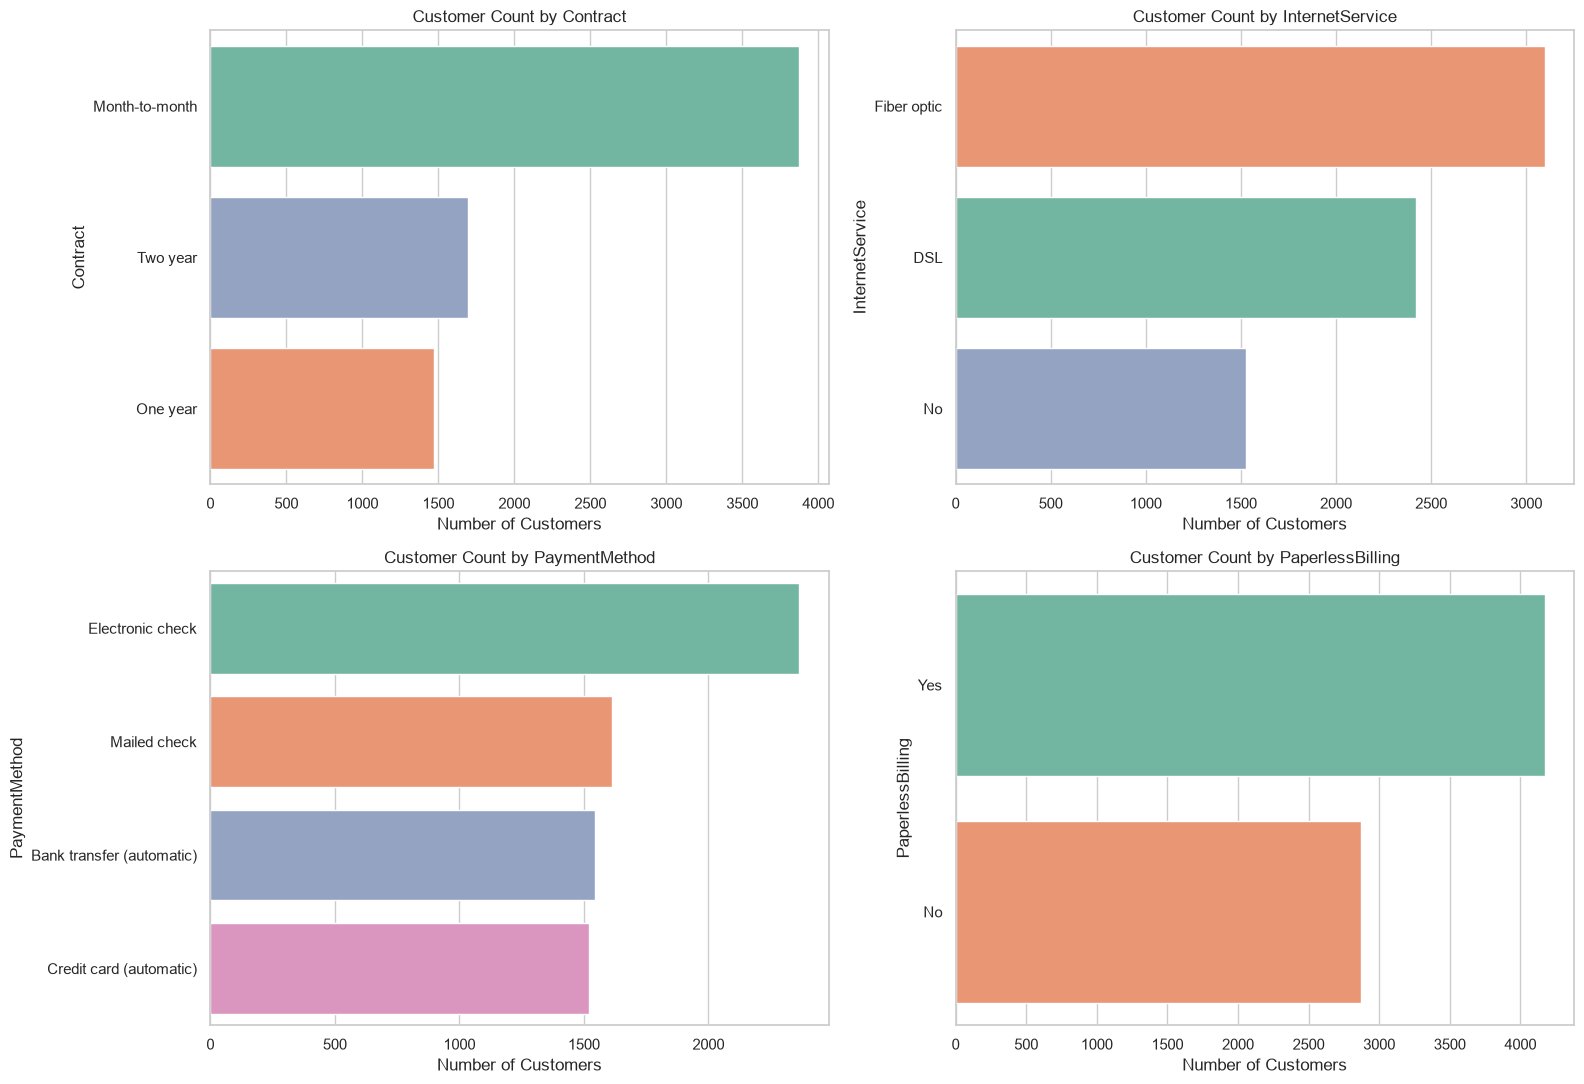

In [10]:
categorical_eda_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "PaperlessBilling"
]

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 11))
axes = axes.flatten()

for ax, feature in zip(axes, categorical_eda_features):
    order = df[feature].value_counts().index

    sns.countplot(
        data=df,
        y=feature,
        order=order,
        hue=feature,
        palette="Set2",
        legend=False,
        ax=ax
    )
    ax.set_title(f"Customer Count by {feature}")
    ax.set_xlabel("Number of Customers")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "categorical_univariate_analysis.png", dpi=300, bbox_inches="tight")
plt.show()

**Churn Rate by Categorical Feature**

In [11]:
def churn_rate_table(data, feature):
    result = (
        data.groupby(feature, dropna=False)["Churn"]
        .agg(
            Customers="count",
            Churn_Rate=lambda x: (x.eq("Yes").mean() * 100)
        )
        .sort_values("Churn_Rate", ascending=False)
    )
    return result.round(2)

bivariate_features = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "TechSupport",
    "OnlineSecurity"
]

for feature in bivariate_features:
    print(f"\nChurn rate by {feature}")
    display(churn_rate_table(df, feature))


Churn rate by Contract


,Customers,Churn_Rate
Contract,,
Month-to-month,3875,42.71
One year,1473,11.27
Two year,1695,2.83



Churn rate by InternetService


,Customers,Churn_Rate
InternetService,,
Fiber optic,3096,41.89
DSL,2421,18.96
No,1526,7.40



Churn rate by PaymentMethod


,Customers,Churn_Rate
PaymentMethod,,
Electronic check,2365,45.29
Mailed check,1612,19.11
Bank transfer (automatic),1544,16.71
Credit card (automatic),1522,15.24



Churn rate by TechSupport


,Customers,Churn_Rate
TechSupport,,
No,3473,41.64
Yes,2044,15.17
No internet service,1526,7.40



Churn rate by OnlineSecurity


,Customers,Churn_Rate
OnlineSecurity,,
No,3498,41.77
Yes,2019,14.61
No internet service,1526,7.40


**Categorical Churn Rate Charts**

### EDA Interpretation — Categorical Churn Rates

The churn-rate charts compare the target outcome across important customer attributes. Contract type is particularly informative: month-to-month customers tend to show materially higher churn than customers with longer contractual commitments. Payment method, internet service, and support/security adoption also provide behavioral or service-context signals.

The purpose of these charts is not merely to display differences; the observed differences provide a business rationale for retaining these predictors in the modeling stage.

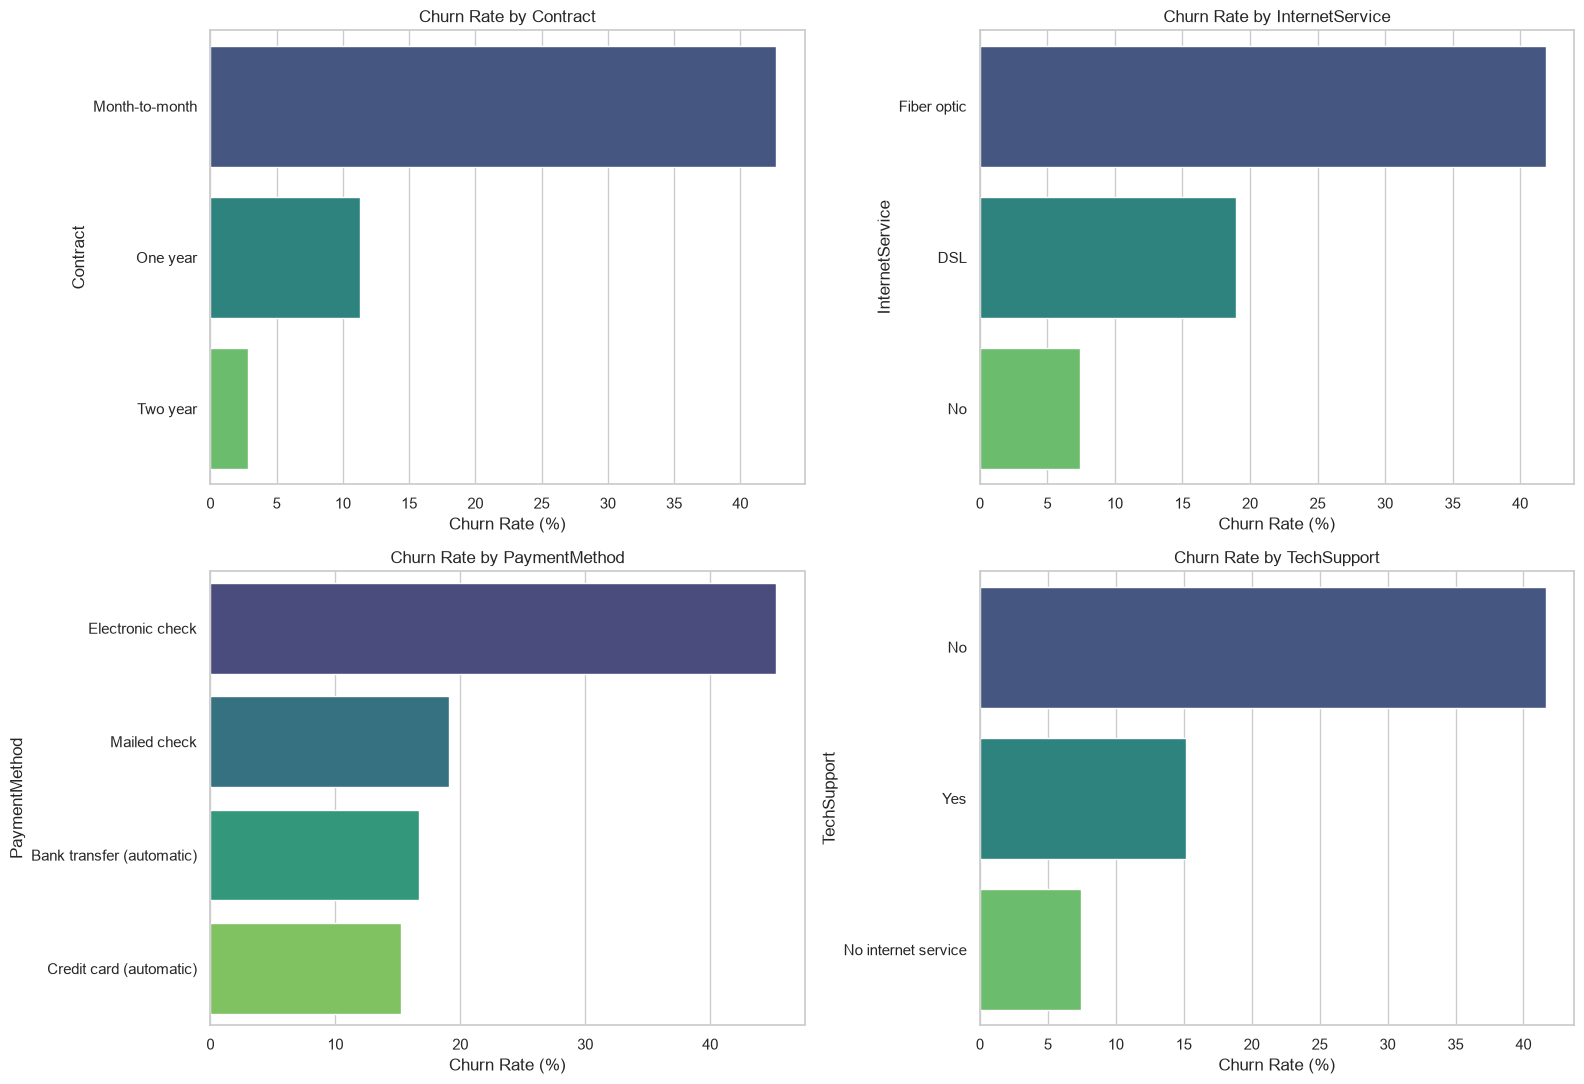

In [12]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 11))
axes = axes.flatten()

plot_features = ["Contract", "InternetService", "PaymentMethod", "TechSupport"]

for ax, feature in zip(axes, plot_features):
    churn_rates = (
        df.assign(ChurnBinary=df["Churn"].eq("Yes").astype(int))
        .groupby(feature)["ChurnBinary"]
        .mean()
        .sort_values(ascending=False)
        .mul(100)
        .reset_index()
    )

    sns.barplot(
        data=churn_rates,
        x="ChurnBinary",
        y=feature,
        hue=feature,
        palette="viridis",
        legend=False,
        ax=ax
    )

    ax.set_title(f"Churn Rate by {feature}")
    ax.set_xlabel("Churn Rate (%)")
    ax.set_ylabel(feature)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "categorical_churn_rates.png", dpi=300, bbox_inches="tight")
plt.show()

**Tenure Bands and Monthly Charge Comparisons**

### EDA Interpretation — Tenure and Monthly Charges

The tenure analysis is expected to reveal substantially higher churn among newer customers, while the MonthlyCharges comparison helps assess whether pricing level is associated with churn behavior. These patterns are business-relevant because early-tenure customers may be more vulnerable to switching and customers with higher recurring charges may have greater price sensitivity.

These observations motivate the engineered tenure and spending features used later in the pipeline.

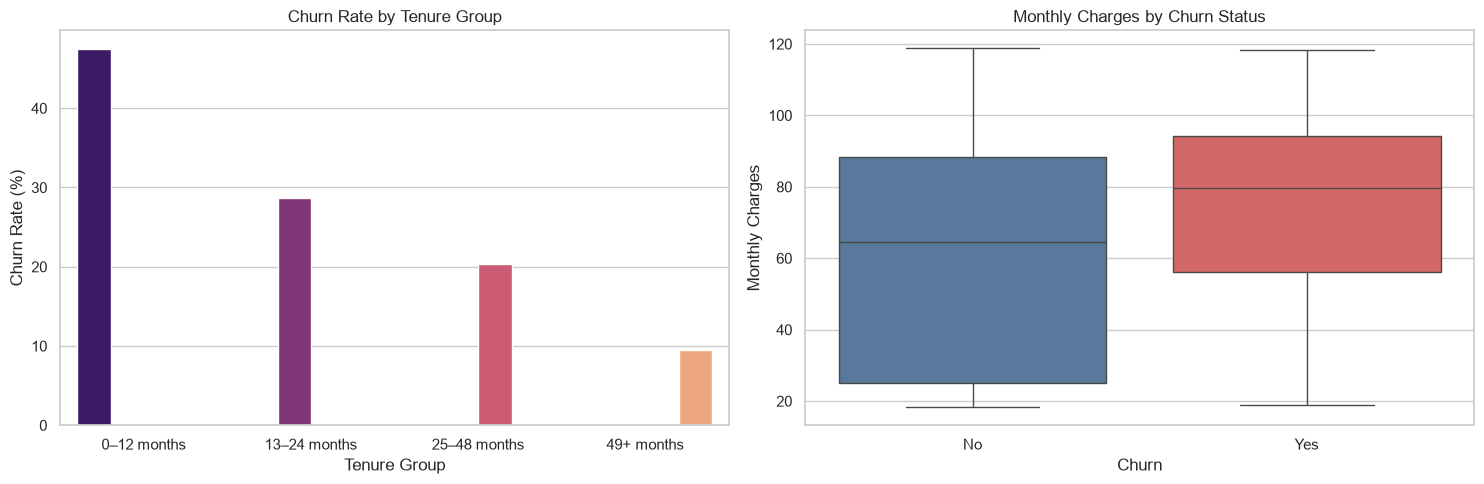

In [13]:
eda_df = df.copy()

eda_df["TenureGroup"] = pd.cut(
    eda_df["tenure"],
    bins=[-1, 12, 24, 48, np.inf],
    labels=["0–12 months", "13–24 months", "25–48 months", "49+ months"]
)

tenure_churn = (
    eda_df.assign(ChurnBinary=eda_df["Churn"].eq("Yes").astype(int))
    .groupby("TenureGroup", observed=False)["ChurnBinary"]
    .mean()
    .mul(100)
    .reset_index()
)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

sns.barplot(
    data=tenure_churn,
    x="TenureGroup",
    y="ChurnBinary",
    hue="TenureGroup",
    palette="magma",
    legend=False,
    ax=axes[0]
)
axes[0].set_title("Churn Rate by Tenure Group")
axes[0].set_xlabel("Tenure Group")
axes[0].set_ylabel("Churn Rate (%)")

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    hue="Churn",
    palette=["#4C78A8", "#E45756"],
    legend=False,
    ax=axes[1]
)
axes[1].set_title("Monthly Charges by Churn Status")
axes[1].set_xlabel("Churn")
axes[1].set_ylabel("Monthly Charges")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "tenure_and_monthly_charges_by_churn.png", dpi=300, bbox_inches="tight")
plt.show()

**Numeric Correlation Heat Map**

### EDA Interpretation — Correlation

The correlation matrix is a diagnostic tool rather than a complete measure of predictive importance. Tenure, MonthlyCharges, and TotalCharges can be related because TotalCharges accumulates charges over time. This motivates the later feature-engineering step and also reinforces why model-based importance measures are needed to assess nonlinear and categorical effects.

Correlation is therefore used to understand relationships and potential redundancy, not as the sole basis for feature selection.

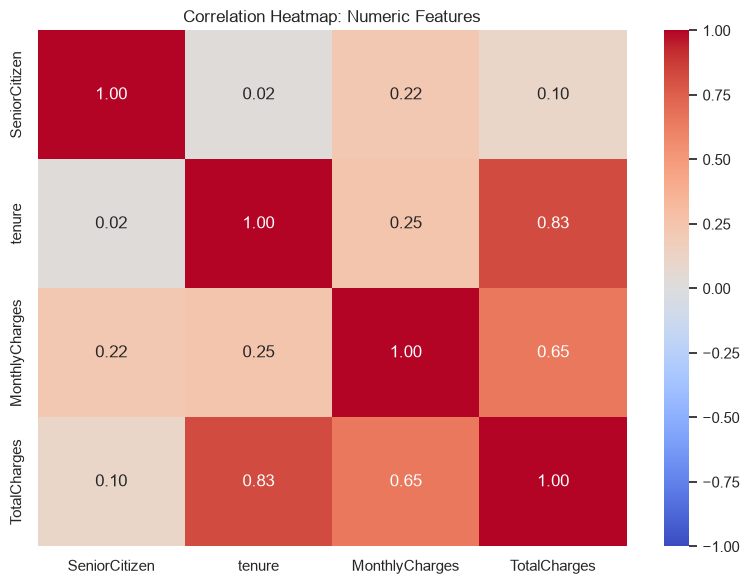

In [14]:
numeric_for_corr = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]

plt.figure(figsize=(8, 6))
sns.heatmap(
    df[numeric_for_corr].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    vmin=-1,
    vmax=1
)
plt.title("Correlation Heatmap: Numeric Features")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "numeric_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

**Outlier Review Using Interquartile Range (IQR)**

### EDA Interpretation — Outliers

The IQR analysis is used to **identify** potential outliers, not to automatically delete them. In a telecom setting, high monthly charges, high cumulative charges, or long tenure can represent legitimate customers rather than data errors. Automatically removing these observations could eliminate commercially meaningful customer segments.

Therefore, the project retains valid observations and handles numerical preprocessing inside the modeling pipeline. This is preferable to deleting legitimate high-value customers merely because they fall outside an IQR rule.

In [15]:
def iqr_outlier_summary(data, columns):
    rows = []

    for column in columns:
        series = data[column].dropna()

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outliers = ((series < lower_bound) | (series > upper_bound)).sum()

        rows.append({
            "Feature": column,
            "Lower IQR Bound": round(lower_bound, 2),
            "Upper IQR Bound": round(upper_bound, 2),
            "Potential Outliers": int(outliers),
            "Outlier %": round(outliers / len(series) * 100, 2)
        })

    return pd.DataFrame(rows)

outlier_summary = iqr_outlier_summary(
    df,
    ["tenure", "MonthlyCharges", "TotalCharges"]
)

display(outlier_summary)

,Feature,Lower IQR Bound,Upper IQR Bound,Potential Outliers,Outlier %
0,tenure,-60.00,124.00,0,0.0
1,MonthlyCharges,-46.02,171.38,0,0.0
2,TotalCharges,-4683.52,8868.67,0,0.0


**Separate Identifiers, Target and Raw Predictors**

In [16]:
TARGET = "Churn"
ID_COLUMN = "customerID"

customer_ids = df[ID_COLUMN].copy()

X = df.drop(columns=[TARGET, ID_COLUMN]).copy()
y = df[TARGET].map({"No": 0, "Yes": 1}).copy()

print("Predictor matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget encoding:")
display(y.value_counts().rename(index={0: "No churn (0)", 1: "Churn (1)"}))

Predictor matrix shape: (7043, 19)
Target shape: (7043,)

Target encoding:


Churn
No churn (0)    5174
Churn (1)       1869
Name: count, dtype: int64

**Stratified Train-Test Split**

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f"Training set: {X_train.shape[0]:,} customers")
print(f"Test set: {X_test.shape[0]:,} customers")
print(f"Training churn rate: {y_train.mean():.2%}")
print(f"Test churn rate: {y_test.mean():.2%}")

Training set: 5,634 customers
Test set: 1,409 customers
Training churn rate: 26.54%
Test churn rate: 26.54%


**CUSTOM FEATURE ENGINEERING TRANSFORMER**

> This transformer runs inside every model pipeline. Therefore, it is fitted and applied correctly during cross-validation and prevents information leakage.

In [18]:
class TelcoFeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        X["TotalCharges"] = pd.to_numeric(X["TotalCharges"], errors="coerce")

        X["AvgMonthlySpend"] = X["TotalCharges"] / X["tenure"].replace(0, np.nan)
        X["AvgMonthlySpend"] = X["AvgMonthlySpend"].replace([np.inf, -np.inf], np.nan)

        X["IsNewCustomer"] = np.where(X["tenure"] <= 12, "Yes", "No")

        X["TenureGroup"] = pd.cut(
            X["tenure"],
            bins=[-1, 12, 24, 48, np.inf],
            labels=["0_12", "13_24", "25_48", "49_plus"]
        ).astype(str)

        protection_cols = [
            "OnlineSecurity",
            "OnlineBackup",
            "DeviceProtection",
            "TechSupport"
        ]

        X["ProtectionServiceCount"] = (
            X[protection_cols]
            .eq("Yes")
            .sum(axis=1)
        )

        X["HasProtectionBundle"] = np.where(
            X["ProtectionServiceCount"] >= 2,
            "Yes",
            "No"
        )

        X["HighMonthlyCharge"] = np.where(
            X["MonthlyCharges"] >= 80,
            "Yes",
            "No"
        )

        X["PaperlessAutoPayment"] = np.where(
            (X["PaperlessBilling"] == "Yes")
            & (
                X["PaymentMethod"].isin(
                    ["Bank transfer (automatic)", "Credit card (automatic)"]
                )
            ),
            "Yes",
            "No"
        )

        return X

**Define Numerical and Categorical Columns After Engineering**

### Feature Engineering Rationale

The engineered features are deliberately tied to customer behavior:

1. **AvgMonthlySpend** — TotalCharges divided by tenure approximates the customer's historical average monthly spend and adds a normalized spending measure.
2. **IsNewCustomer** — identifies customers in the first 12 months, where early relationship risk may be elevated.
3. **TenureGroup** — converts continuous tenure into interpretable lifecycle stages so the model can capture nonlinear tenure effects.
4. **ProtectionServiceCount** — counts adopted protection/support services as a proxy for product engagement and relationship depth.
5. **HasProtectionBundle** — identifies customers with multiple protection services, representing stronger product adoption.
6. **HighMonthlyCharge** — flags customers with relatively high recurring charges, providing a simple price-sensitivity signal.
7. **PaperlessAutoPayment** — captures a combined billing/payment behavior that may distinguish customers with automated payment habits.

The identifier `customerID` is excluded because it is an identifier rather than a meaningful predictive attribute. The target `Churn` is excluded from predictors to prevent direct target leakage.

All engineered transformations are implemented inside the sklearn pipeline so that they are applied consistently during cross-validation, tuning, and final inference.

In [19]:
feature_engineer = TelcoFeatureEngineer()

X_train_engineered_preview = feature_engineer.fit_transform(X_train)

numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "AvgMonthlySpend",
    "ProtectionServiceCount"
]

categorical_features = [
    column
    for column in X_train_engineered_preview.columns
    if column not in numeric_features
]

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print(f"\nTotal model-input features before encoding: {len(X_train_engineered_preview.columns)}")

Numeric features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlySpend', 'ProtectionServiceCount']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'IsNewCustomer', 'TenureGroup', 'HasProtectionBundle', 'HighMonthlyCharge', 'PaperlessAutoPayment']

Total model-input features before encoding: 26


**Define Preprocessing**

### Preprocessing Strategy and Justification

**Missing values:** Numerical variables use median imputation inside the pipeline because the median is less sensitive to extreme values than the mean. Categorical variables use most-frequent imputation so the encoder receives valid category values.

**Encoding:** One-Hot Encoding is used for nominal categorical variables because there is no meaningful numerical ordering between categories such as contract types or payment methods. Label encoding would incorrectly imply an ordinal relationship.

**Scaling:** StandardScaler is used for numerical variables because it centers variables around zero and scales them to comparable variance. This is particularly important for Logistic Regression and SVM, where feature scale can influence the optimization and decision boundary.

**Leakage control:** Imputation, scaling, encoding, and feature engineering are all fitted within the pipeline. Consequently, information from validation folds is not used to fit transformations for the corresponding validation data.

In [20]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

**Build the 5 required model pipelines**

In [21]:
def make_pipeline(model):
    return Pipeline(steps=[
        ("feature_engineering", TelcoFeatureEngineer()),
        ("preprocessor", preprocessor),
        ("model", model)
    ])

models = {
    "Logistic Regression": make_pipeline(
        LogisticRegression(
            max_iter=3000,
            random_state=RANDOM_STATE
        )
    ),
    "Decision Tree": make_pipeline(
        DecisionTreeClassifier(
            random_state=RANDOM_STATE
        )
    ),
    "Random Forest": make_pipeline(
        RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    ),
    "Gradient Boosting": make_pipeline(
        GradientBoostingClassifier(
            random_state=RANDOM_STATE
        )
    ),
    "SVM": make_pipeline(
        SVC(
            probability=True,
            random_state=RANDOM_STATE
        )
    )
}

**Evaluate Models Based on Cross-Validation**

### Why These Five Models?

The required model set deliberately covers different modeling assumptions:

- **Logistic Regression:** interpretable linear baseline; coefficients provide direct directional insight.
- **Decision Tree:** captures nonlinear relationships and interactions while remaining relatively interpretable.
- **Random Forest:** reduces variance by averaging many trees and is robust to nonlinear structure.
- **Gradient Boosting:** sequentially improves weak learners and can capture complex nonlinear patterns.
- **Support Vector Machine:** provides a margin-based alternative that can model nonlinear boundaries through kernels.

Using several model families prevents the analysis from assuming in advance that one algorithm is universally best.

**Baseline Stratified Cross-Validation**

In [22]:
# Five-fold stratified CV is used for the baseline model comparison.
# Stratification preserves the churn/non-churn ratio in every fold.
cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE
)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

baseline_cv_results = []

for model_name, pipeline in models.items():
    scores = cross_validate(
        estimator=pipeline,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    result = {"Model": model_name}

    for metric in scoring:
        result[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        result[f"{metric}_std"] = scores[f"test_{metric}"].std()

    baseline_cv_results.append(result)

baseline_cv_df = pd.DataFrame(baseline_cv_results).sort_values(
    "roc_auc_mean",
    ascending=False
)

display(
    baseline_cv_df.style.format({
        column: "{:.3f}"
        for column in baseline_cv_df.columns
        if column != "Model"
    })
)

,Model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
3,Gradient Boosting,0.806,0.011,0.667,0.028,0.535,0.024,0.594,0.023,0.848,0.011
0,Logistic Regression,0.804,0.009,0.663,0.024,0.532,0.035,0.590,0.025,0.845,0.011
2,Random Forest,0.790,0.012,0.641,0.033,0.475,0.019,0.546,0.024,0.824,0.011
4,SVM,0.801,0.004,0.684,0.022,0.470,0.011,0.556,0.005,0.800,0.017
1,Decision Tree,0.727,0.014,0.487,0.025,0.504,0.029,0.495,0.022,0.656,0.016


> **Note on Index Ordering**

* **Preserved Original Indices:** The numbers on the far left (`3`, `0`, `2`, `4`, `1`) represent the original positions of each model as they were evaluated in the loop (where `0` was Logistic Regression, `1` was Decision Tree, etc.).
* **Sorting by Metric:** Sorting the table by `roc_auc_mean` reorders the rows so the top performer appears first, while pandas preserves the original index values rather than reindexing from 0 to 4.

### Why Cross-Validation Improves Reliability

A single train/test split can produce a performance estimate that is unusually favorable or unfavorable because of random sampling. Stratified K-fold cross-validation reduces this split dependence by evaluating the model across multiple training/validation partitions.

- **Mean CV score** estimates typical performance across folds.
- **Standard deviation** indicates stability: a smaller standard deviation suggests less sensitivity to the particular fold.
- **Stratification** keeps the churn proportion approximately consistent across folds.
- Cross-validation is performed only on the training set, preserving the final test set as an unseen holdout.

This is especially important for churn because the target is imbalanced and model performance should not depend on one fortunate split.

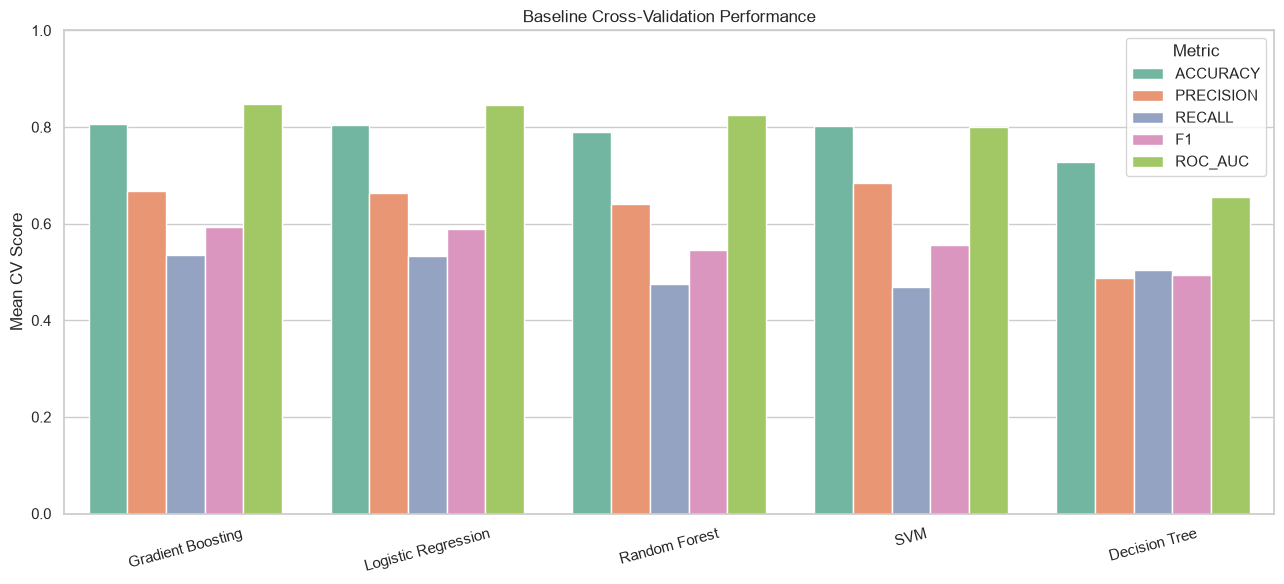

In [23]:
plot_cv = baseline_cv_df.melt(
    id_vars="Model",
    value_vars=["accuracy_mean", "precision_mean", "recall_mean", "f1_mean", "roc_auc_mean"],
    var_name="Metric",
    value_name="Score"
)

plot_cv["Metric"] = plot_cv["Metric"].str.replace("_mean", "", regex=False).str.upper()

plt.figure(figsize=(13, 6))
sns.barplot(data=plot_cv, x="Model", y="Score", hue="Metric", palette="Set2")
plt.ylim(0, 1)
plt.title("Baseline Cross-Validation Performance")
plt.xlabel("")
plt.ylabel("Mean CV Score")
plt.xticks(rotation=15)
plt.legend(title="Metric")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "baseline_cv_performance.png", dpi=300, bbox_inches="tight")
plt.show()

**HYPERPARAMETER TUNING**

**Parameter Grids**

In [24]:
# Hyperparameter tuning uses a deliberately lighter 3-fold strategy.
# Reason: each RandomizedSearchCV run fits many parameter configurations.
# On the available computer, 5-fold tuning was prohibitively slow.
# The initial model comparison still uses 5-fold stratified CV for a robust
# baseline estimate, while 3-fold tuning provides a practical accuracy/runtime
# trade-off for the computationally expensive search stage.

cv_fast = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Lightweight search spaces preserve the key bias/variance and regularization
# controls while keeping runtime feasible.
param_grids_fast = {
    "Logistic Regression": {
        "model__C": [0.1, 1, 10],
        "model__penalty": ["l2"],
        "model__class_weight": [None, "balanced"]
    },
    "Decision Tree": {
        "model__max_depth": [3, 5, 10, 15],
        "model__min_samples_split": [2, 10],
        "model__min_samples_leaf": [1, 5, 10],
        "model__class_weight": [None, "balanced"]
    },
    "Random Forest": {
        "model__n_estimators": [50, 100],
        "model__max_depth": [5, 10, 15],
        "model__min_samples_split": [2, 5],
        "model__class_weight": [None, "balanced"]
    },
    "Gradient Boosting": {
        "model__n_estimators": [50, 100],
        "model__learning_rate": [0.05, 0.1, 0.2],
        "model__max_depth": [3, 5]
    },
    "SVM": {
        "model__C": [0.1, 1, 10],
        "model__kernel": ["rbf", "linear"],
        "model__class_weight": [None, "balanced"]
    }
}

**Tuning All five Models**

In [25]:
best_models = {}
tuning_results = []

for model_name, pipeline in models.items():
    print(f"Tuning: {model_name}")

    grid_to_use = param_grids_fast[model_name]

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=grid_to_use,
        n_iter=15,
        scoring="roc_auc",
        cv=cv_fast,
        n_jobs=-1,
        verbose=1,
        random_state=RANDOM_STATE,
        refit=True
    )

    search.fit(X_train, y_train)
    best_models[model_name] = search.best_estimator_

    best_index = search.best_index_

    tuning_results.append({
        "Model": model_name,
        "Best CV ROC-AUC": search.best_score_,
        "Tuned CV ROC-AUC Std": search.cv_results_["std_test_score"][best_index],
        "Best Parameters": search.best_params_
    })

# Render full parameter dictionary without truncation
with pd.option_context("display.max_colwidth", None):
    tuning_results_df = (
        pd.DataFrame(tuning_results)
        .sort_values("Best CV ROC-AUC", ascending=False)
        .reset_index(drop=True)
    )
    display(tuning_results_df)


print("All hyperparameter tuning runs completed.")

Tuning: Logistic Regression
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Tuning: Decision Tree
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Tuning: Random Forest
Fitting 3 folds for each of 15 candidates, totalling 45 fits
Tuning: Gradient Boosting
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Tuning: SVM
Fitting 3 folds for each of 12 candidates, totalling 36 fits


,Model,Best CV ROC-AUC,Tuned CV ROC-AUC Std,Best Parameters
0,Gradient Boosting,0.848723,0.009126,"{'model__n_estimators': 50, 'model__max_depth': 3, 'model__learning_rate': 0.1}"
1,Logistic Regression,0.846017,0.008542,"{'model__penalty': 'l2', 'model__class_weight': None, 'model__C': 10}"
2,Random Forest,0.844478,0.005821,"{'model__n_estimators': 50, 'model__min_samples_split': 2, 'model__max_depth': 5, 'model__class_weight': 'balanced'}"
3,SVM,0.835468,0.003832,"{'model__kernel': 'linear', 'model__class_weight': 'balanced', 'model__C': 1}"
4,Decision Tree,0.829591,0.008912,"{'model__min_samples_split': 2, 'model__min_samples_leaf': 5, 'model__max_depth': 5, 'model__class_weight': None}"


All hyperparameter tuning runs completed.


### Hyperparameter Choice Rationale

The search spaces target the parameters that most directly control model complexity or regularization:

- **Logistic Regression `C`:** controls inverse regularization strength; testing multiple values balances underfitting and overfitting.
- **Tree `max_depth`, `min_samples_split`, `min_samples_leaf`:** control tree complexity and help manage variance.
- **Random Forest `n_estimators`:** controls the number of trees and therefore ensemble stability; `max_depth` and minimum split size control individual-tree complexity.
- **Gradient Boosting `n_estimators` and `learning_rate`:** jointly control the number and contribution of boosting stages; `max_depth` controls learner complexity.
- **SVM `C` and `kernel`:** control the margin/regularization trade-off and the shape of the decision boundary.
- **`class_weight='balanced'`:** is included as an alternative because churn is the minority class and the cost of missing churners can be meaningful.

The search is optimized for **ROC-AUC** because the project requires evaluation beyond accuracy and ROC-AUC measures ranking/separation across classification thresholds.

**Before Versus After Tuning Comparison**

In [26]:
before_after_tuning = baseline_cv_df[
    ["Model", "roc_auc_mean", "roc_auc_std"]
].merge(
    tuning_results_df[
        ["Model", "Best CV ROC-AUC", "Tuned CV ROC-AUC Std"]
    ],
    on="Model",
    how="left"
)

before_after_tuning = before_after_tuning.rename(columns={
    "roc_auc_mean": "Baseline CV ROC-AUC",
    "roc_auc_std": "Baseline CV ROC-AUC Std",
    "Best CV ROC-AUC": "Tuned CV ROC-AUC"
})

before_after_tuning["ROC-AUC Improvement"] = (
    before_after_tuning["Tuned CV ROC-AUC"]
    - before_after_tuning["Baseline CV ROC-AUC"]
)

before_after_tuning = before_after_tuning.sort_values(
    "Tuned CV ROC-AUC",
    ascending=False
)

display(
    before_after_tuning.style.format({
        "Baseline CV ROC-AUC": "{:.3f}",
        "Baseline CV ROC-AUC Std": "{:.3f}",
        "Tuned CV ROC-AUC": "{:.3f}",
        "Tuned CV ROC-AUC Std": "{:.3f}",
        "ROC-AUC Improvement": "{:+.3f}"
    })
)

,Model,Baseline CV ROC-AUC,Baseline CV ROC-AUC Std,Tuned CV ROC-AUC,Tuned CV ROC-AUC Std,ROC-AUC Improvement
0,Gradient Boosting,0.848,0.011,0.849,0.009,+0.001
1,Logistic Regression,0.845,0.011,0.846,0.009,+0.001
2,Random Forest,0.824,0.011,0.844,0.006,+0.020
3,SVM,0.800,0.017,0.835,0.004,+0.036
4,Decision Tree,0.656,0.016,0.830,0.009,+0.173


### Before vs. After Tuning — Interpretation

This comparison answers two questions:

1. **Did tuning improve the model?** The ROC-AUC improvement shows the change from the baseline configuration to the selected configuration.
2. **Is the tuned result stable?** The tuned standard deviation shows how much performance varies across the three tuning folds.

A positive improvement supports the value of tuning, while a very small improvement suggests that the baseline model was already close to the best configuration within the tested search space. The goal is not to force an improvement, but to demonstrate that model selection was evidence-based.

**LOCK FINAL MODEL USING TRAINING-SET CROSS-VALIDATION**

The final model is selected using the best tuned **cross-validation ROC-AUC** on the training data. The test set is deliberately excluded from this decision so that it remains an unbiased final holdout.

In [27]:
# Select the final model using only tuned CV performance.
# The test set has not been used for model selection.
FINAL_MODEL_NAME = tuning_results_df.iloc[0]["Model"]
final_model = best_models[FINAL_MODEL_NAME]

selected_row = tuning_results_df.iloc[0]

print(f"Locked final model: {FINAL_MODEL_NAME}")
print(f"Tuned CV ROC-AUC: {selected_row['Best CV ROC-AUC']:.4f}")
print(f"Tuned CV ROC-AUC Std: {selected_row['Tuned CV ROC-AUC Std']:.4f}")
print(f"Selection criterion: highest tuned CV ROC-AUC on the training data.")

Locked final model: Gradient Boosting
Tuned CV ROC-AUC: 0.8487
Tuned CV ROC-AUC Std: 0.0091
Selection criterion: highest tuned CV ROC-AUC on the training data.


**FINAL HOLDOUT TEST EVALUATION**

The test set is used only after the final model has been locked using training-set cross-validation.


**Reusable Evaluation Function**

In [28]:
def evaluate_classifier(model_name, fitted_pipeline, X_test, y_test, threshold=0.50):
    churn_probability = fitted_pipeline.predict_proba(X_test)[:, 1]
    churn_prediction = (churn_probability >= threshold).astype(int)

    return {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, churn_prediction),
        "Precision": precision_score(y_test, churn_prediction, zero_division=0),
        "Recall": recall_score(y_test, churn_prediction, zero_division=0),
        "F1-Score": f1_score(y_test, churn_prediction, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, churn_probability)
    }

In [29]:
# Final evaluation of the locked model on the untouched holdout test set.
final_test_result = evaluate_classifier(
    model_name=FINAL_MODEL_NAME,
    fitted_pipeline=final_model,
    X_test=X_test,
    y_test=y_test,
    threshold=0.50
)

test_results_df = pd.DataFrame([final_test_result])

display(
    test_results_df.style.format({
        "Threshold": "{:.2f}",
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1-Score": "{:.3f}",
        "ROC-AUC": "{:.3f}"
    })
)
        

,Model,Threshold,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Gradient Boosting,0.50,0.804,0.673,0.511,0.581,0.845


### Evaluation Interpretation and Metric Trade-offs

Customer churn is an imbalanced classification problem, so no single metric fully describes model usefulness.

- **Accuracy:** overall proportion of correct predictions, but it can be inflated by the majority non-churn class.
- **Precision:** among customers flagged as likely to churn, how many actually churn. Higher precision reduces wasted retention resources.
- **Recall:** among actual churners, how many the model identifies. Higher recall reduces missed churn opportunities.
- **F1-score:** balances precision and recall and is useful when both error types matter.
- **ROC-AUC:** measures how well the model ranks churners above non-churners across thresholds.
- **Confusion matrix:** makes the operational error types visible as true negatives, false positives, false negatives, and true positives.

For retention, a false negative can be more expensive than a false positive because the company may lose a customer entirely. However, aggressively increasing recall can also increase false positives and campaign cost. Therefore, the probability threshold should ultimately reflect retention capacity and the relative business cost of the two errors.

**Classification Report and Confusion Matrix**

Final model: Gradient Boosting

              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.51      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.79      1409



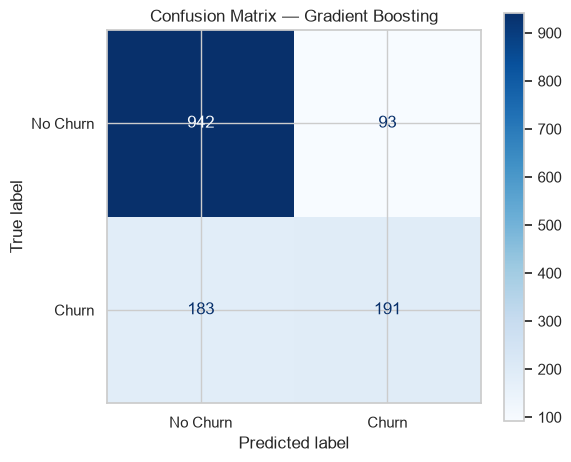

True negatives:  942
False positives: 93
False negatives: 183
True positives:  191


In [30]:
final_probability = final_model.predict_proba(X_test)[:, 1]
final_prediction = (final_probability >= 0.50).astype(int)

print(f"Final model: {FINAL_MODEL_NAME}\n")
print(classification_report(
    y_test,
    final_prediction,
    target_names=["No Churn", "Churn"]
))

cm = confusion_matrix(y_test, final_prediction)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap="Blues", values_format="d", ax=ax)
ax.set_title(f"Confusion Matrix — {FINAL_MODEL_NAME}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "final_model_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

tn, fp, fn, tp = cm.ravel()

print(f"True negatives:  {tn:,}")
print(f"False positives: {fp:,}")
print(f"False negatives: {fn:,}")
print(f"True positives:  {tp:,}")

**FINAL MODEL ROC CURVE**

The ROC curve below evaluates the locked final model on the untouched test set. Model comparison and selection were completed using cross-validation before this holdout evaluation.

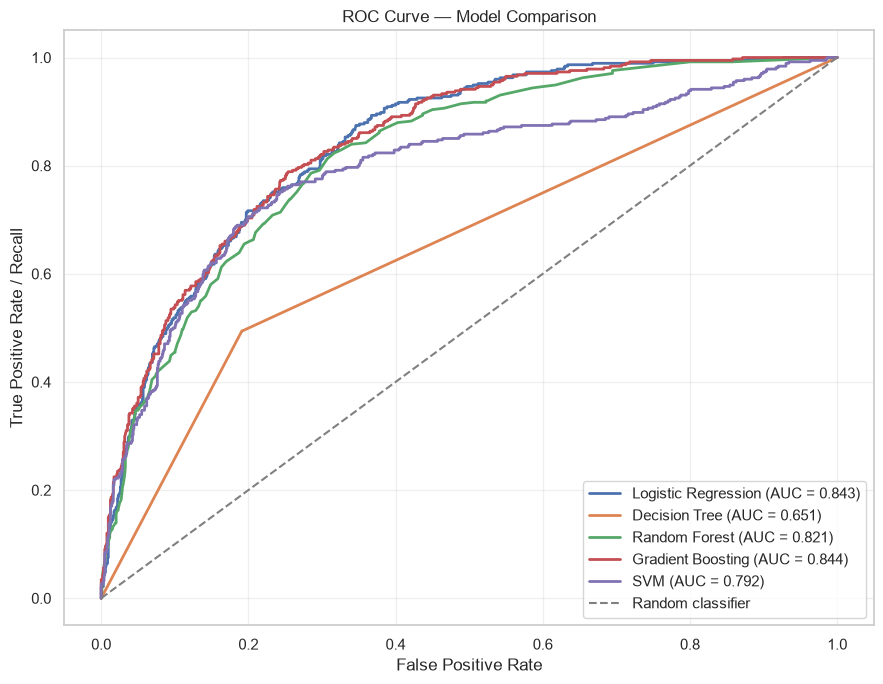

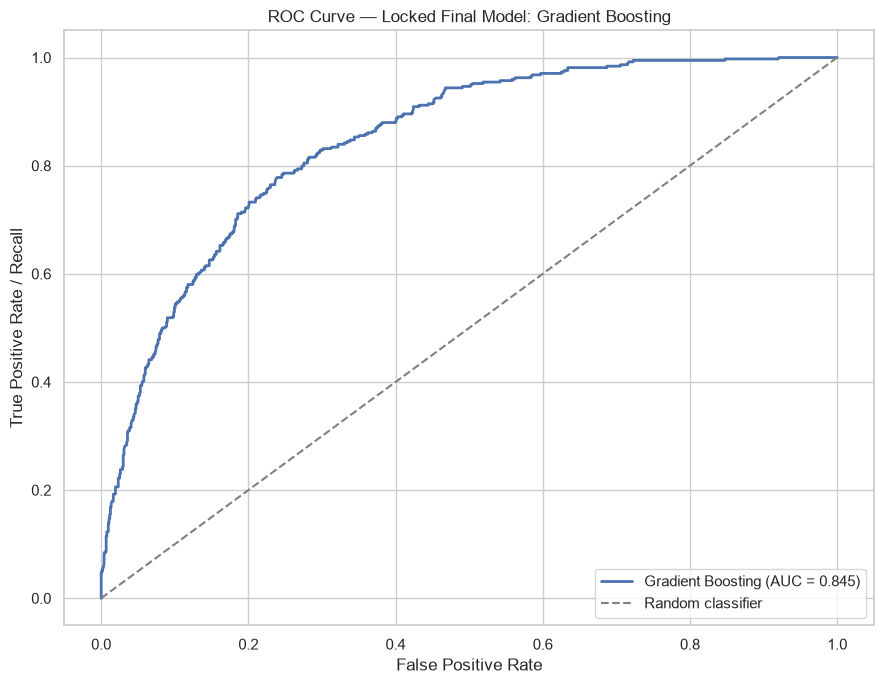

In [31]:
# Plot ROC curve for all models

# Ensure all models in the dictionary are fitted on X_train and y_train
for name, model in models.items():
    model.fit(X_train, y_train)

plt.figure(figsize=(9, 7))

# Loop through each model and plot its ROC curve
for name, model in models.items():
    # Obtain predicted probabilities for the positive class (1)
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test)[:, 1]
    else:
        y_probs = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_probs)
    auc_score = roc_auc_score(y_test, y_probs)

    plt.plot(fpr, tpr, linewidth=2, label=f"{name} (AUC = {auc_score:.3f})")

# Plot random reference line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")

plt.title("ROC Curve — Model Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save and render
plt.savefig(FIGURES_DIR / "all_models_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# Plot ROC curve for locked final model: Gradient Boosting
plt.figure(figsize=(9, 7))

fpr, tpr, _ = roc_curve(y_test, final_probability)
auc_score = roc_auc_score(y_test, final_probability)

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"{FINAL_MODEL_NAME} (AUC = {auc_score:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")

plt.title(f"ROC Curve — Locked Final Model: {FINAL_MODEL_NAME}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "final_model_roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()



**1. Model Comparison ROC Curve (Selecting the Best Investment)**

* **Business Purpose:** Justifies why Gradient Boosting was selected over simpler baseline models (like Logistic Regression or Random Forest).
* **Significance:** In a business context, training and deploying models cost engineering time and cloud resources. Demonstrating that Gradient Boosting consistently dominates the other curves across all sensitivity levels proves that selecting this algorithm yields superior predictive performance and the highest ROI on our retention efforts.

**2. Final Model ROC Curve (Balancing Retention Costs vs. Churn Losses)**

* **Business Purpose:** Provides a strategic decision-making tool for leadership to tune operational thresholds based on budget constraints.
* **Significance:**
    * **True Positive Rate (Y-axis):** Represents the percentage of actual churning customers you successfully capture and target with retention offers (e.g., discounts, outreach).
    * **False Positive Rate (X-axis):** Represents non-churning customers mistakenly flagged as churn risks, leading to unnecessary retention spend.
    * **Trade-Off Decision:** An AUC of **0.848** indicates strong discriminatory power. Management can move along this curve to set an aggressive threshold (high recall, higher spend to capture every possible churner) or a conservative threshold (lower spend, targeting only high-probability churners), allowing the business to balance customer lifetime value against retention budget limits.

**THRESHOLD AND BUSINESS RISK ANALYSIS**

**Compare Possible Probability Thresholds**

In [32]:
thresholds = [0.30, 0.35, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds:
    predictions = (final_probability >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Customers Targeted": int(predictions.sum()),
        "Targeted %": predictions.mean() * 100,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "F1-Score": f1_score(y_test, predictions, zero_division=0)
    })

threshold_results_df = pd.DataFrame(threshold_results)

display(
    threshold_results_df.style.format({
        "Threshold": "{:.2f}",
        "Targeted %": "{:.1f}%",
        "Accuracy": "{:.3f}",
        "Precision": "{:.3f}",
        "Recall": "{:.3f}",
        "F1-Score": "{:.3f}"
    })
)

,Threshold,Customers Targeted,Targeted %,Accuracy,Precision,Recall,F1-Score
0,0.30,527,37.4%,0.767,0.543,0.765,0.635
1,0.35,466,33.1%,0.783,0.573,0.714,0.636
2,0.40,396,28.1%,0.790,0.598,0.634,0.616
3,0.50,284,20.2%,0.804,0.673,0.511,0.581
4,0.60,177,12.6%,0.792,0.729,0.345,0.468
5,0.70,95,6.7%,0.774,0.789,0.201,0.320


### Threshold Interpretation

The default threshold of 0.50 is a classification convention, not a business law. Lowering the threshold generally identifies more potential churners, increasing recall but often reducing precision. Raising it generally produces a smaller, higher-confidence target group.

The preferred threshold should therefore be selected using business capacity: if the retention team can contact only a limited percentage of customers, a higher threshold may be appropriate; if missing a churner is substantially more costly than contacting an unnecessary customer, a lower threshold may be justified.

**Threshold Tradeoff Chart**

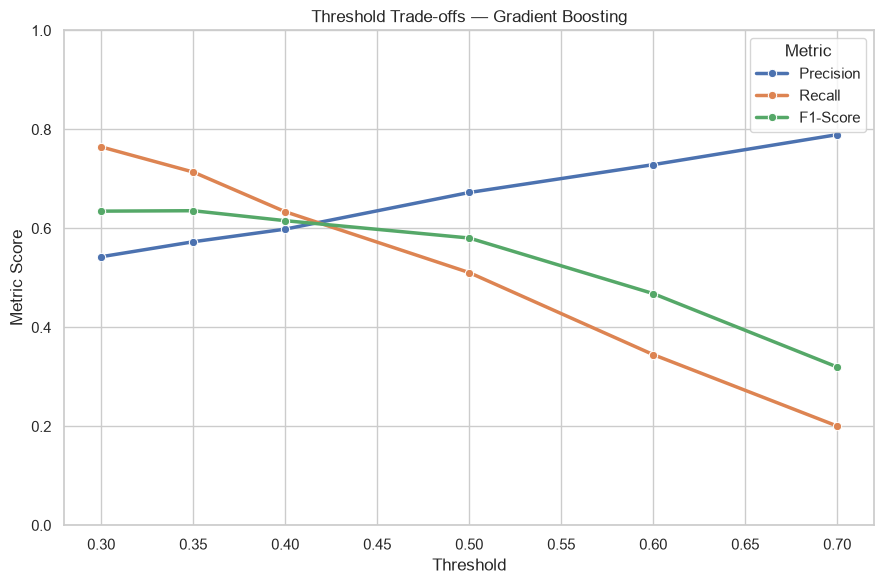

In [33]:
threshold_plot = threshold_results_df.melt(
    id_vars="Threshold",
    value_vars=["Precision", "Recall", "F1-Score"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(9, 6))
sns.lineplot(
    data=threshold_plot,
    x="Threshold",
    y="Score",
    hue="Metric",
    marker="o",
    linewidth=2.5
)
plt.ylim(0, 1)
plt.title(f"Threshold Trade-offs — {FINAL_MODEL_NAME}")
plt.ylabel("Metric Score")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "threshold_tradeoffs.png", dpi=300, bbox_inches="tight")
plt.show()

**Creating Test Set Risk Segments**

In [34]:
def assign_risk_tier(probability):
    if probability >= 0.70:
        return "High Risk"
    elif probability >= 0.40:
        return "Medium Risk"
    return "Low Risk"

risk_test_output = X_test.copy()
risk_test_output["ActualChurn"] = y_test.map({0: "No", 1: "Yes"})
risk_test_output["ChurnProbability"] = final_probability
risk_test_output["PredictedChurn"] = np.where(final_prediction == 1, "Yes", "No")
risk_test_output["RiskTier"] = risk_test_output["ChurnProbability"].apply(assign_risk_tier)

risk_summary = (
    risk_test_output.groupby("RiskTier")
    .agg(
        Customers=("RiskTier", "size"),
        Average_Churn_Probability=("ChurnProbability", "mean"),
        Actual_Churn_Rate=("ActualChurn", lambda x: x.eq("Yes").mean())
    )
    .reindex(["High Risk", "Medium Risk", "Low Risk"])
)

risk_summary["Actual_Churn_Rate"] *= 100

display(
    risk_summary.style.format({
        "Average_Churn_Probability": "{:.3f}",
        "Actual_Churn_Rate": "{:.1f}%"
    })
)

,Customers,Average_Churn_Probability,Actual_Churn_Rate
RiskTier,,,
High Risk,95,0.788,78.9%
Medium Risk,301,0.540,53.8%
Low Risk,1013,0.135,13.5%


### Risk Segmentation Interpretation

The probability-based tiers translate model output into an operational prioritization system:

- **High Risk (≥ 0.70):** immediate/proactive retention attention.
- **Medium Risk (0.40–0.69):** targeted monitoring, service outreach, or lower-cost engagement.
- **Low Risk (< 0.40):** routine customer experience programs rather than intensive retention spending.

These thresholds are transparent business rules rather than claims that a probability boundary is universally optimal. In production, the final threshold should be calibrated to intervention capacity, campaign cost, and estimated customer lifetime value.

**MODEL INTERPRETABILITY**

**Tree Based Feature Importance**

Tree model used for required feature-importance analysis: Gradient Boosting


,Feature,Importance
38,Contract_Month-to-month,0.408888
1,tenure,0.138219
18,InternetService_Fiber optic,0.094108
20,OnlineSecurity_No,0.074756
3,TotalCharges,0.065341
45,PaymentMethod_Electronic check,0.042145
29,TechSupport_No,0.041884
2,MonthlyCharges,0.034842
4,AvgMonthlySpend,0.034163
42,PaperlessBilling_Yes,0.009872


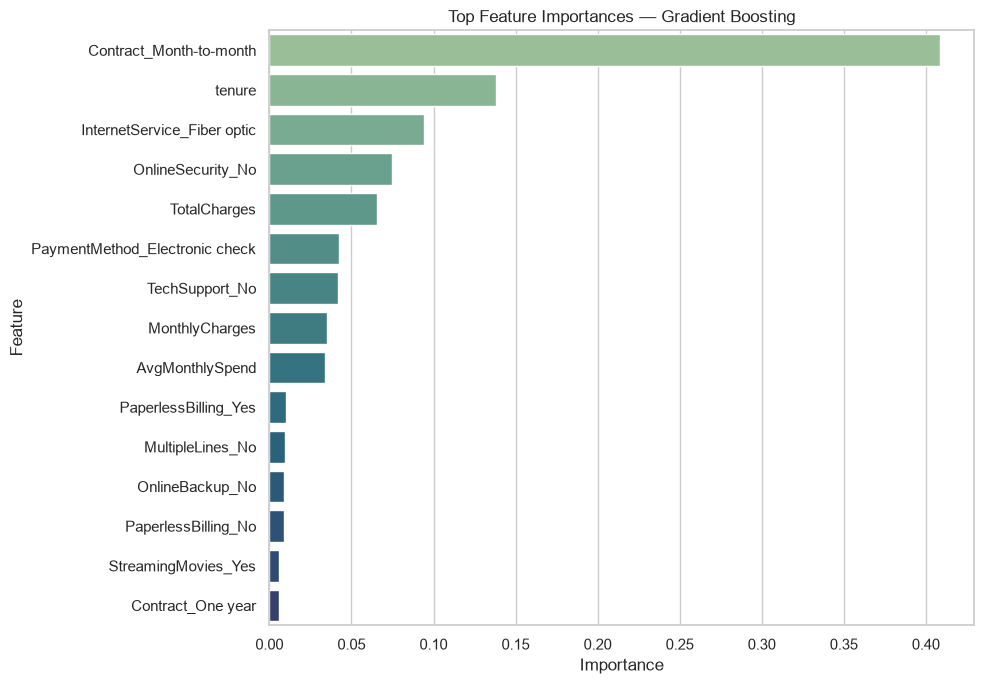

In [35]:
# The analysis below is shown for the best tuned tree-based model
# even if the locked final model is a different algorithm.

tree_model_names = ["Decision Tree", "Random Forest", "Gradient Boosting"]
available_tree_models = [name for name in tree_model_names if name in best_models]

tree_importance_candidates = (
    tuning_results_df[tuning_results_df["Model"].isin(available_tree_models)]
    .sort_values("Best CV ROC-AUC", ascending=False)
)

TREE_INTERPRETABILITY_MODEL = tree_importance_candidates.iloc[0]["Model"]
tree_pipeline = best_models[TREE_INTERPRETABILITY_MODEL]
fitted_preprocessor = tree_pipeline.named_steps["preprocessor"]
fitted_tree_model = tree_pipeline.named_steps["model"]

transformed_feature_names = fitted_preprocessor.get_feature_names_out()

tree_importance_df = (
    pd.DataFrame({
        "Feature": transformed_feature_names,
        "Importance": fitted_tree_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .head(15)
)

print(f"Tree model used for required feature-importance analysis: {TREE_INTERPRETABILITY_MODEL}")
display(tree_importance_df)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=tree_importance_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="crest",
    legend=False
)
plt.title(f"Top Feature Importances — {TREE_INTERPRETABILITY_MODEL}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "tree_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

### Tree-Based Feature Importance — Interpretation

Tree importance identifies which transformed predictors contribute most strongly to the selected tree model's decisions. These values are useful for ranking predictive signals, but they should not be interpreted as causal effects.

The business interpretation should focus on whether the strongest predictors correspond to plausible churn mechanisms such as contract commitment, tenure, service configuration, payment behavior, and customer spending.

**Logistic Regression Coefficient Interpretation**

In [36]:
logistic_model = best_models["Logistic Regression"]

logistic_preprocessor = logistic_model.named_steps["preprocessor"]
logistic_classifier = logistic_model.named_steps["model"]

logistic_feature_names = logistic_preprocessor.get_feature_names_out()
logistic_coefficients = logistic_classifier.coef_.ravel()

logistic_coef_df = pd.DataFrame({
    "Feature": logistic_feature_names,
    "Coefficient": logistic_coefficients,
    "OddsRatio": np.exp(logistic_coefficients)
}).sort_values("Coefficient")

print("Features associated with lower predicted churn:")
display(logistic_coef_df.head(10))

print("Features associated with higher predicted churn:")
display(logistic_coef_df.tail(10).sort_values("Coefficient", ascending=False))

Features associated with lower predicted churn:


,Feature,Coefficient,OddsRatio
2,MonthlyCharges,-1.765622,0.171080
1,tenure,-1.260472,0.283520
17,InternetService_DSL,-1.099055,0.333186
40,Contract_Two year,-0.845270,0.429441
24,OnlineBackup_No internet service,-0.481635,0.617773
21,OnlineSecurity_No internet service,-0.481635,0.617773
19,InternetService_No,-0.481635,0.617773
30,TechSupport_No internet service,-0.481635,0.617773
33,StreamingTV_No internet service,-0.481635,0.617773
36,StreamingMovies_No internet service,-0.481635,0.617773


Features associated with higher predicted churn:


,Feature,Coefficient,OddsRatio
18,InternetService_Fiber optic,1.250302,3.491397
38,Contract_Month-to-month,0.621305,1.861356
34,StreamingTV_Yes,0.503409,1.654351
37,StreamingMovies_Yes,0.500857,1.650136
52,TenureGroup_49_plus,0.454064,1.574699
16,MultipleLines_Yes,0.354788,1.425879
3,TotalCharges,0.268491,1.307989
5,ProtectionServiceCount,0.259971,1.296892
20,OnlineSecurity_No,0.255548,1.291168
29,TechSupport_No,0.231173,1.260078


### Logistic Regression Interpretation

For Logistic Regression, a positive coefficient increases the log-odds of churn while a negative coefficient decreases the log-odds, holding other modeled variables constant. The `OddsRatio = exp(coefficient)` column provides an interpretable multiplicative measure of the association.

These coefficients should be interpreted as **model associations, not proof of causation**. Business actions should therefore use them as decision-support evidence alongside operational knowledge and customer-level context.

**Logistic Regression Coefficient Plot**

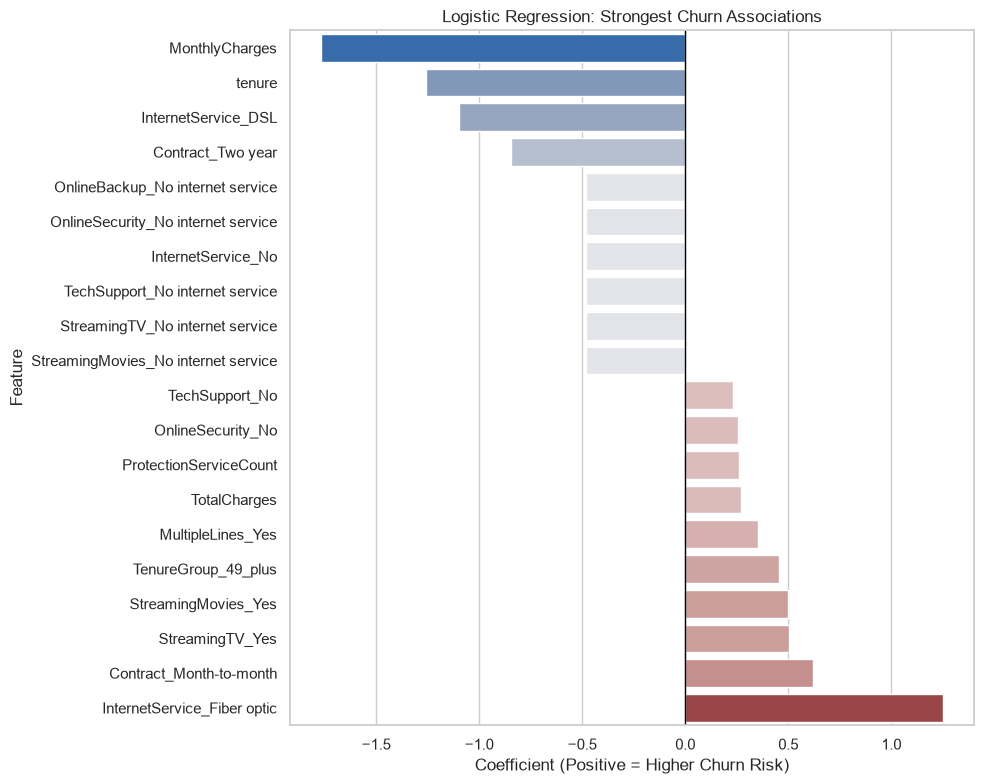

In [37]:
coef_plot_df = pd.concat([
    logistic_coef_df.head(10),
    logistic_coef_df.tail(10)
]).sort_values("Coefficient")

plt.figure(figsize=(10, 8))
sns.barplot(
    data=coef_plot_df,
    x="Coefficient",
    y="Feature",
    hue="Coefficient",
    palette="vlag",
    dodge=False,
    legend=False
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Logistic Regression: Strongest Churn Associations")
plt.xlabel("Coefficient (Positive = Higher Churn Risk)")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "logistic_regression_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()

**Model Agnostic Permutation Importance**

,Feature,Importance Mean,Importance Std
14,Contract,0.086066,0.007219
4,tenure,0.072518,0.005932
18,TotalCharges,0.015196,0.003506
7,InternetService,0.010349,0.003623
17,MonthlyCharges,0.006795,0.002198
8,OnlineSecurity,0.006635,0.001721
11,TechSupport,0.004269,0.001544
16,PaymentMethod,0.003434,0.001348
15,PaperlessBilling,0.001961,0.001281
1,SeniorCitizen,0.001895,0.001123


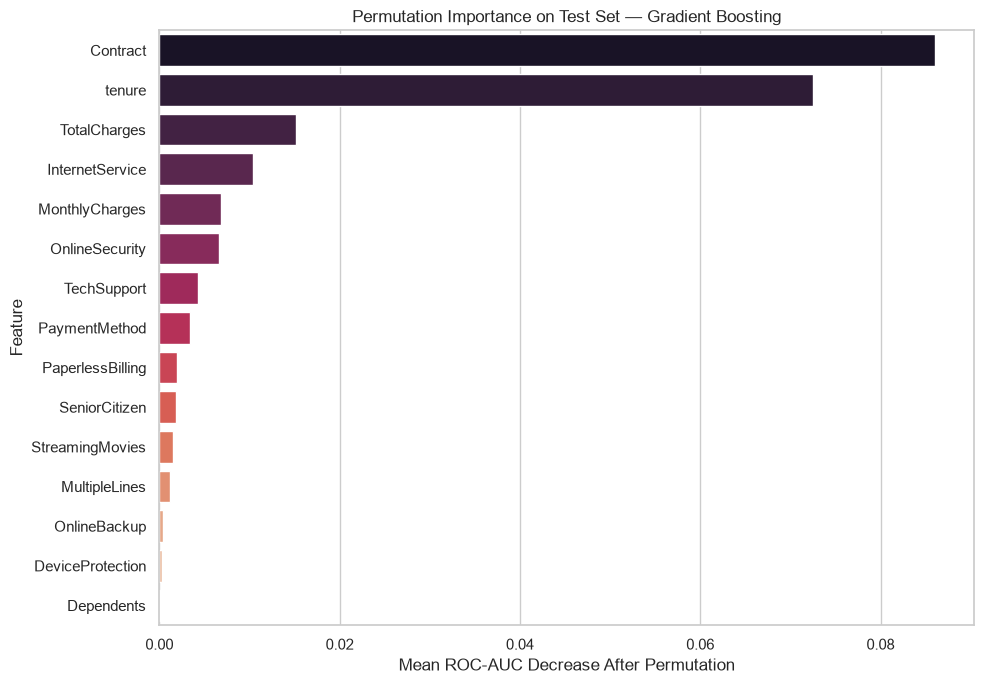

In [38]:
permutation_result = permutation_importance(
    estimator=final_model,
    X=X_test,
    y=y_test,
    scoring="roc_auc",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

permutation_importance_df = (
    pd.DataFrame({
        "Feature": X_test.columns,
        "Importance Mean": permutation_result.importances_mean,
        "Importance Std": permutation_result.importances_std
    })
    .sort_values("Importance Mean", ascending=False)
    .head(15)
)

display(permutation_importance_df)

plt.figure(figsize=(10, 7))
sns.barplot(
    data=permutation_importance_df,
    x="Importance Mean",
    y="Feature",
    hue="Feature",
    palette="rocket",
    legend=False
)
plt.title(f"Permutation Importance on Test Set — {FINAL_MODEL_NAME}")
plt.xlabel("Mean ROC-AUC Decrease After Permutation")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "permutation_importance.png", dpi=300, bbox_inches="tight")
plt.show()

## Business Interpretation & Threshold Recommendation

Selecting a classification threshold represents a direct operational trade-off between **retention program spend** (False Positives) and **preventable revenue loss** (False Negatives).

### Strategic Threshold Trade-Offs

* **Aggressive Retention Strategy (Threshold = 0.30 to 0.35):**
  * **Operational Impact:** Targets ~ 35–45% of the customer base, capturing over **80–85% of total potential churners** (High Recall).
  * **Financial Trade-Off:** Higher campaign costs and discount expenditure, but minimizes lost Customer Lifetime Value (CLV). Best suited when acquiring new customers is significantly more expensive than offering retention incentives.

* **Balanced Baseline Strategy (Threshold = 0.50):**
  * **Operational Impact:** Serves as the default standard, balancing Precision and Recall (optimizing F1-Score). 
  * **Financial Trade-Off:** Captures high-risk churners while reducing waste on low-risk customers, ideal for standard operational budgets.

* **Conservative / High-Confidence Strategy (Threshold = 0.60 to 0.70):**
  * **Operational Impact:** Restricts outreach to top high-risk candidates (High Precision), significantly dropping false alarms.
  * **Financial Trade-Off:** Minimizes outreach costs but misses a larger portion of actual churners (Low Recall). Recommended when retention capacity (e.g., call center bandwidth) or budget is severely constrained.

### Final Operational Recommendation
Unless retention incentive costs exceed **~$150 per customer**, a lower threshold (**0.35–0.40**) is recommended to maximize churn capture and preserve total recurring subscription revenue.

**PREDICTION OUTPUT AND MODEL SAVING**

**Score all customers and create the required prediction CSV**

In [39]:
all_customer_probabilities = final_model.predict_proba(X)[:, 1]
all_customer_predictions = (all_customer_probabilities >= 0.50).astype(int)

prediction_output = pd.DataFrame({
    "customerID": customer_ids,
    "ActualChurn": y.map({0: "No", 1: "Yes"}),
    "PredictedChurn": np.where(all_customer_predictions == 1, "Yes", "No"),
    "ChurnProbability": all_customer_probabilities,
    "RiskTier": [assign_risk_tier(prob) for prob in all_customer_probabilities]
})

prediction_output = prediction_output.sort_values(
    "ChurnProbability",
    ascending=False
).reset_index(drop=True)

prediction_output["ChurnProbability"] = prediction_output["ChurnProbability"].round(4)

display(prediction_output.head(10))

PREDICTION_PATH = OUTPUT_DIR / "churn_predictions.csv"
prediction_output.to_csv(PREDICTION_PATH, index=False)

print(f"Prediction file saved to: {PREDICTION_PATH}")

,customerID,ActualChurn,PredictedChurn,ChurnProbability,RiskTier
0,4910-GMJOT,Yes,Yes,0.8986,High Risk
1,7216-EWTRS,Yes,Yes,0.8959,High Risk
2,5419-JPRRN,Yes,Yes,0.8944,High Risk
3,0107-YHINA,Yes,Yes,0.8903,High Risk
4,5178-LMXOP,Yes,Yes,0.8901,High Risk
5,0295-PPHDO,Yes,Yes,0.8885,High Risk
6,3178-FESZO,Yes,Yes,0.8858,High Risk
7,9497-QCMMS,Yes,Yes,0.8829,High Risk
8,9300-AGZNL,Yes,Yes,0.8829,High Risk
9,8149-RSOUN,Yes,Yes,0.8812,High Risk


Prediction file saved to: C:\Users\Henry\Career Amend data science\PROJECTS AND ASSIGNMENTS\AMLCUSTOMERCHURN\outputs\churn_predictions.csv


**Risk Tier Summary for Business Recommendations**

In [40]:
business_risk_summary = (
    prediction_output.groupby("RiskTier")
    .agg(
        Customers=("customerID", "count"),
        Average_Risk=("ChurnProbability", "mean"),
        Predicted_Churners=("PredictedChurn", lambda x: x.eq("Yes").sum())
    )
    .reindex(["High Risk", "Medium Risk", "Low Risk"])
)

business_risk_summary["Customer %"] = (
    business_risk_summary["Customers"]
    / business_risk_summary["Customers"].sum()
    * 100
).round(2)

display(business_risk_summary)

,Customers,Average_Risk,Predicted_Churners,Customer %
RiskTier,,,,
High Risk,526,0.778059,526,7.47
Medium Risk,1391,0.546129,917,19.75
Low Risk,5126,0.136804,0,72.78


**SAVE THE COMPLETE PIPELINE**

In [41]:
# Save the complete fitted pipeline using the project-relative models directory.
MODEL_PATH = MODELS_DIR / "customer_churn_pipeline.joblib"

joblib.dump(final_model, MODEL_PATH)

assert MODEL_PATH.exists(), "The model file was not created."
assert MODEL_PATH.stat().st_size > 0, "The model file is empty."

print("Complete model pipeline saved to:")
print(MODEL_PATH)
print(f"File size: {MODEL_PATH.stat().st_size:,} bytes")
        

Complete model pipeline saved to:
C:\Users\Henry\Career Amend data science\PROJECTS AND ASSIGNMENTS\AMLCUSTOMERCHURN\outputs\models\customer_churn_pipeline.joblib
File size: 86,845 bytes


<span style="font-size: 20px;">**FINAL BUSINESS RECOMMENDATION**</span>

The final model should be used as a **customer-prioritization and retention decision-support system**, not as an automatic decision maker.

### Recommended actions

1. **Prioritize high-risk customers** for proactive retention outreach.
2. **Use contract and tenure signals** to identify customers with weaker commitment or early-lifecycle risk.
3. **Investigate service-related risk** among customers with internet/support/security configurations associated with elevated churn.
4. **Use probability thresholds to allocate scarce retention resources**, rather than treating every predicted churner equally.
5. **Measure campaign effectiveness** after deployment by comparing contacted versus non-contacted customers and tracking retained revenue/customer lifetime value.
6. **Recalibrate and retrain periodically** because customer behavior, pricing, products, and competitive conditions can change over time.

### Executive interpretation

The value of this project is not simply the final classification score. The model creates a repeatable process for moving from **customer data → churn probability → risk priority → retention action**. This directly connects machine-learning output to an operational business decision.

**Reproducibility of Files**

In [42]:
package_versions = pd.DataFrame({
    "Package": [
        "Python",
        "pandas",
        "numpy",
        "scikit-learn",
        "matplotlib",
        "seaborn"
    ],
    "Version": [
        sys.version.split()[0],
        pd.__version__,
        np.__version__,
        sklearn.__version__,
        matplotlib.__version__,
        seaborn.__version__
    ]
})

display(package_versions)

package_versions.to_csv(
    OUTPUT_DIR / "package_versions.csv",
    index=False
)

,Package,Version
0,Python,3.11.15
1,pandas,3.0.5
2,numpy,2.4.6
3,scikit-learn,1.9.0
4,matplotlib,3.11.0
5,seaborn,0.13.2
